# Datenanalyse mit SQL & Python - Tag 3: Python, Pandas & Visualisierung

**Struktur:** Vormittag zuerst, Nachmittag danach.  
**Vormittag:** SQL-Recap, Transfer von SQL zu Pandas, Python-Grundlagen und Arbeiten mit Daten in Pandas.  
**Nachmittag:** Datenvisualisierung mit Matplotlib & Seaborn und Mini-Projekt.


## Ablauf

| Zeit | Abschnitt | Fokus |
|---|---|---|
| 09:00-09:30 | Wiederholung | SQL-Denken aus Tag 2: `GROUP BY`, `HAVING`, CTEs |
| 09:30-10:30 | Python-Grundlagen | `print`, Operatoren, Variablen, `if/else`, Schleifen |
| 10:30-11:30 | Arbeiten mit Daten | Pandas, DataFrames, Filtern, Sortieren, einfache Kennzahlen, Merge/Join |
| 11:30-12:10 | Mittagspause | - |
| 12:10-12:40 | Transfer SQL zu Pandas | Gleiche Analysefrage zuerst in SQL, dann in Pandas lösen |
| 12:40-14:00 | Datenvisualisierung | Matplotlib, Seaborn, Diagrammtypen, erste Insights |
| 14:00-14:20 | Pause | - |
| 14:20-15:40 | Mini-Projekt | Analysefrage wählen, Daten erkunden, Diagramme erstellen |
| 15:40-16:00 | Ergebnisse & Diskussion | Erkenntnisse teilen, Ausblick auf Tag 4 |


## Lernziele

Nach Tag 3 kannst du:

- einfache Python-Anweisungen lesen und schreiben
- Variablen, Bedingungen und Schleifen verwenden
- Daten mit Pandas laden, prüfen, filtern und zusammenfassen
- Tabellen mit Pandas zusammenführen
- einfache Diagramme mit Matplotlib und Seaborn erstellen
- aus Visualisierungen erste fachliche Aussagen ableiten


# 09:00-09:30 | Wiederholung: SQL-Denken aus Tag 2

Bevor wir in Python einsteigen, aktivieren wir noch einmal die Denkweise aus Tag 2:

- Welche Tabelle brauche ich?
- Welche Zeilen filtere ich vor der Gruppierung?
- Welche Kennzahl berechne ich pro Gruppe?
- Wann brauche ich `HAVING`, Subquery oder CTE?


In [ ]:
import sqlite3
import numpy as np
import pandas as pd

BUDGET_RECAP_URL = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/household_budget.csv'

budget_recap = pd.read_csv(BUDGET_RECAP_URL)
budget_recap['date'] = pd.to_datetime(budget_recap['date'])
budget_recap['month'] = budget_recap['date'].dt.strftime('%Y-%m')

conn_recap = sqlite3.connect(':memory:')
budget_recap.to_sql('budget', conn_recap, index=False, if_exists='replace')

budget_recap.head()


,date,category,description,amount,type,month
0,2024-02-01,Entertainment,Entertainment payment,-265,Expense,2024-02
1,2024-01-19,Rent,Rent payment,-191,Expense,2024-01
2,2024-03-09,Transport,Transport payment,-196,Expense,2024-03
3,2024-02-18,Dining,Dining payment,-173,Expense,2024-02
4,2024-03-13,Utilities,Utilities payment,-227,Expense,2024-03


In [ ]:
query = '''
SELECT
    category,
    SUM(amount) AS expenses
FROM budget
WHERE type = 'Expense'
GROUP BY category
ORDER BY expenses DESC;
'''

pd.read_sql_query(query, conn_recap)

,category,expenses
0,Groceries,-668
1,Transport,-784
2,Utilities,-1081
3,Rent,-1352
4,Entertainment,-1812
5,Dining,-2237


In [ ]:
query = '''
SELECT
    category,
    SUM(amount) AS expenses
FROM budget
WHERE type = 'Expense'
GROUP BY category
HAVING -SUM(amount) > 100
ORDER BY expenses DESC;
'''

pd.read_sql_query(query, conn_recap)


,category,expenses
0,Groceries,-668
1,Transport,-784
2,Utilities,-1081
3,Rent,-1352
4,Entertainment,-1812
5,Dining,-2237


In [ ]:
query = '''
WITH monthly_totals AS (
    SELECT
        month,
        SUM(CASE WHEN type = 'Income' THEN amount ELSE -amount END) AS net_amount
    FROM budget
    GROUP BY month
)
SELECT *
FROM monthly_totals
ORDER BY net_amount DESC;
'''

pd.read_sql_query(query, conn_recap)


,month,net_amount
0,2024-01,13695
1,2024-03,9139
2,2024-02,6637


# 09:30–10:30 | Python-Grundlagen

### Google Drive verbinden (optional)

Falls du mit Daten aus deinem Google Drive arbeiten möchtest, kannst du es wie folgt verbinden:



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Danach kannst du auf Dateien in deinem Drive zugreifen, z.B.:

In [ ]:
# Example: Reading a CSV from Google Drive
# Uncomment and modify the path to use:
# import pandas as pd
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/course_data/automobile_dataset.csv')
# df.head()

### Übung: Daten in Google Drive speichern und lesen

Lade einen Beispieldatensatz herunter und speichere ihn in deinem Google Drive. Lese ihn danach wieder ein, um sicherzustellen, dass die Verbindung funktioniert.

In [ ]:
import requests

# Beispiel-URL für einen Datensatz
sample_data_url = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/shop/shop_products.csv'
local_file_name = 'shop_products.csv'

# Pfad in Google Drive
gdrive_path = f'/content/drive/MyDrive/Colab Notebooks/{local_file_name}'

# Herunterladen und in Google Drive speichern
response = requests.get(sample_data_url)
if response.status_code == 200:
    with open(gdrive_path, 'wb') as f:
        f.write(response.content)
    print(f'Datei erfolgreich in Google Drive gespeichert: {gdrive_path}')
else:
    print(f'Fehler beim Herunterladen der Datei. Statuscode: {response.status_code}')

Datei erfolgreich in Google Drive gespeichert: /content/drive/MyDrive/shop_products.csv


In [ ]:
import pandas as pd

# Datei aus Google Drive lesen
try:
    df_products_from_drive = pd.read_csv(gdrive_path)
    print('\nErste 5 Zeilen der aus Google Drive gelesenen Datei:')
    display(df_products_from_drive.head())
except FileNotFoundError:
    print(f'Fehler: Die Datei {gdrive_path} wurde nicht gefunden. Stellen Sie sicher, dass sie in Ihrem Google Drive existiert.')
except Exception as e:
    print(f'Ein Fehler ist aufgetreten beim Lesen der Datei: {e}')


Erste 5 Zeilen der aus Google Drive gelesenen Datei:


,product_id,product_name,category,price
0,101,Running Shoes,Sports,137
1,102,Ceramic Table Lamp,Home,68
2,103,Cotton T-Shirt,Fashion,41
3,104,Yoga Mat,Sports,65
4,105,Kitchen Towel Set,Home,13


## **Dein erstes Python Programm**
    
**Ziel:** Die Teilnehmenden lernen, wie man mit `print()` Text und Rechenergebnisse ausgibt.

- print “Hello World!”
- Operators and print results

## 🧩 Hello World!

In [ ]:
# Schreibe dein erstes Programm!
print("Hello World!")
print("Herzlich willkommen zum Python-Kurs!")

Hello World!
Herzlich willkommen zum Python-Kurs!


### Übung:

- Gib mit print() deinen Namen aus
→ **Beispiel:** print("Mein Name ist …")

- Gib mit print() einen kurzen Satz aus, der deinen ersten Eindruck von Deep Learning beschreibt
→ **Beispiel:**
print("Deep Learning klingt spannend, aber auch ein bisschen komplex.")

## 🧩 Operatoren ausprobieren

In [ ]:
# Verwende +, -, *, /, % (Rest) und ** (Potenz)
print("3 + 2 =", 3 + 2)
print("10 - 4 =", 10 - 4)
print("6 * 7 =", 6 * 7)
# / (Division) → normale Division, Ergebnis ist immer eine Dezimalzahl (Float)
print("8 / 2 =", 8 / 2)
# // (Ganzzahl-Division) → teilt und rundet das Ergebnis nach unten ab
print("8 // 2 =", 8 // 2)
# % (Modulo) → gibt den Rest der Division zurück
print("10 % 3 =", 10 % 3)
# ** Potenz (Exponent) → also 2 hoch 3
print("2 ** 3 =", 2 ** 3)

3 + 2 = 5
10 - 4 = 6
6 * 7 = 42
8 / 2 = 4.0
8 // 2 = 4
10 % 3 = 1
2 ** 3 = 8


### Übung:

- Gib mit print() "9 / 2" und "9 // 2" und "9 % 2" aus und erklären den Unterschied.

- Rechnen mit Klammern (7 + (2 * 9)) // 5

- Füge eigenen Text hinzu oder kombiniere mehrere Berechnungen in einer Zeile.

**Merke**

- Klammern bestimmen die Reihenfolge
- und * und / werden vor + und - ausgeführt

- // und % sind besonders nützlich für Zählprobleme, Aufteilungen und Indizes

# **Variables**
    
**Ziel:** Verstehen, wie Informationen gespeichert und mit Text kombiniert werden.
    
- Dein Info (Name: string, Beruf: string, Alter: Integer, Kinder: boolean, Jahre der Beruferfahrung: float)
- Variablen erstellen und print text verbunden mit der Variablen
- If-Else-Verzweigung

## 🧩 Persönliche Daten und Datentypen in Python (Data Types)

In [ ]:
# Erstelle Variablen zu dir selbst

# Text (String)
name = "Alex"
beruf = "Data Scientist"

# Ganze Zahl (Integer)
alter = 32

# Wahrheitswert (Boolean)
kinder = False

# Dezimalzahl (Float)
erfahrung = 5.5

print("Mein Name ist", name)
print("Ich arbeite als", beruf, "und habe", erfahrung, "Jahre Erfahrung.")
# Leere Zeile
print("")
# oder
print("oder")
# Leere Zeile
print("")
print("Mein Name ist " + name + ". " + "Ich bin " + str(alter) + " Jahre alt und habe " + str(erfahrung) + " Jahre Erfahrung. " + "Ich arbeite als " + beruf + ". " + "Habe ich Kinder? " + str(kinder))

Mein Name ist Alex
Ich arbeite als Data Scientist und habe 5.5 Jahre Erfahrung.

oder

Mein Name ist Alex. Ich bin 32 Jahre alt und habe 5.5 Jahre Erfahrung. Ich arbeite als Data Scientist. Habe ich Kinder? False


### Übung: Bitte einen kurzen Text mit Erstellung der Variablen über dich schreiben und print().

name = "Max"

alter = 35

stadt = "Berlin"

interesse = "Künstliche Intelligenz"

lernt_python = True

print(
  "Mein Name ist " + name + ". "
  + "Ich bin " + str(alter) + " Jahre alt. "
  + "Ich lebe in " + stadt + ". "
  + "Mein Interesse ist " + interesse + ". "
  + "Lerne ich gerade Python? " + str(lernt_python)
  )

## 🧩 If-Else-Verzweigung

In [ ]:
# Prüfe, ob jemand berufserfahren ist
if erfahrung > 3:
    print(name, "ist erfahren!")
else:
    print(name, "ist noch Anfänger.")

Alex ist erfahren!


In [ ]:
if alter >= 18:
    print(name, "ist volljährig.")
else:
    print(name, "ist minderjährig.")

Alex ist volljährig.


### Übung:

Erstelle eine If-Else-Verzweigung, die überprüft, ob eine Person Kinder hat.

- Wenn kinder ist True, gib aus: „(Name) hat Kinder.“

- Wenn kinder ist False, gib aus: „(Name) hat keine Kinder.“

# **Loop**

**Ziel:** Wiederholte Aufgaben mit for- und while-Schleifen ausführen.

- For Schleife

- While Schleife

## 🧩 For-Schleife

In [ ]:
# Zahlen von 0 bis 5 ausgeben
for i in range(6):
    print("Zahl:", i)

Zahl: 0
Zahl: 1
Zahl: 2
Zahl: 3
Zahl: 4
Zahl: 5


In [ ]:
# Zahlen von 1 bis 5 ausgeben
for i in range(1, 6):
    print("Zahl:", i)

Zahl: 1
Zahl: 2
Zahl: 3
Zahl: 4
Zahl: 5


**Zahlen von 0 bis einschließlich 10 mit Schrittweite 2 ausgeben**

range(start, stop, step) erzeugt eine Zahlenfolge

- start = 0 → Startwert

- stop = 10 → 10 ist nicht enthalten

- step = 2 → Schrittweite 2

In [ ]:
# Zahlen von 0 bis einschließlich 10 mit Schrittweite 2 ausgeben
for i in range(0, 10, 2) :
    print("Zahl:", i)

Zahl: 0
Zahl: 2
Zahl: 4
Zahl: 6
Zahl: 8


In [ ]:
farben = ["Rot", "Grün", "Blau"]
for farbe in farben:
    print("Ich mag die Farbe", farbe)

Ich mag die Farbe Rot
Ich mag die Farbe Grün
Ich mag die Farbe Blau


### Übung:

- Zahlen von 0 bis einschließlich 19 mit Schrittweite 3 ausgeben

- Gibt print() mit einen Tierlist aus. List 3 Tiere, die du magst und print "Ich mag (Tier)"

## 🧩 While-Schleife

In [ ]:
# Countdown von 5 bis 1
x = 5
while x > 0:
    print("Countdown:", x)
    x -= 1 # x = x-1
print("Start!")

Countdown: 5
Countdown: 4
Countdown: 3
Countdown: 2
Countdown: 1
Start!


In [ ]:
# Zahlenraten-Spiel
zahl = 3
versuch = 0

while versuch != zahl:
    versuch = int(input("Rate eine Zahl zwischen 1 und 5: "))
    if versuch == zahl:
        print("Richtig!")
    else:
        print("Falsch, versuch es nochmal.")

Rate eine Zahl zwischen 1 und 5: 3
Richtig!


# 🧩 **Abschlussübung – Dein persönlicher Mini-Assistent**

**Ziel:** Verwende alles, was du gelernt hast: Variablen, Operatoren, If-Else, und Loops.

**Dauer:** ca. 15 min

### ✅ **Aufgabe**

Erstelle ein Programm, das:

1. persönliche Informationen abfragt
2. eine kleine Entscheidung trifft (z. B. Empfehlung oder Feedback gibt)
3. eine Schleife nutzt, um den Benutzer mehrfach interagieren zu lassen

In [ ]:
# --- Beispiel: Dein persönlicher Assistent ---

print("👋 Willkommen zu deinem Mini-Assistenten!")

# 1. Eingaben
name = input("Wie heißt du? ")
alter = int(input("Wie alt bist du? "))
beruf = input("Was ist dein Beruf? ")

# 2. Bedingungen
if alter < 18:
    print("Hallo", name + "!", "Du bist noch jung – viel Spaß beim Lernen!")
elif alter < 30:
    print("Cool,", name + "!", "Ein perfektes Alter, um Python-Profi zu werden.")
else:
    print("Hi", name + "!", "Man lernt nie aus – großartig, dass du dabei bist!")

# 3. Schleife
for i in range(1,4):
    print("🤖 Runde", i, ":", name, "arbeitet als", beruf)

print("✅ Programm beendet – gute Arbeit,", name + "!")

👋 Willkommen zu deinem Mini-Assistenten!
Wie heißt du? 3
Wie alt bist du? 67
Was ist dein Beruf? 687
Hi 3! Man lernt nie aus – großartig, dass du dabei bist!
🤖 Runde 1 : 3 arbeitet als 687
🤖 Runde 2 : 3 arbeitet als 687
🤖 Runde 3 : 3 arbeitet als 687
✅ Programm beendet – gute Arbeit, 3!


# 10:30–11:30 | Arbeiten mit Daten (Pandas)

### 🔹 Lernziele

Nach dieser Einheit können Teilnehmende:

- Pandas importieren und ein DataFrame erstellen
- Daten aus einer CSV-Datei laden
- Datensätze anzeigen, filtern und einfache Berechnungen durchführen
- Grundlegende Statistikfunktionen anwenden

### **Pandas importieren und DataFrame erstellen**

In [ ]:
import pandas as pd

# Erstelle ein einfaches DataFrame
data = {
    "Name": ["Anna", "Ben", "Clara", "David", "Eva"],
    "Alter": [28, 35, 22, 41, 50],
    "Startjahr": [2020, 2015, 2023, 2010, 2020]
}

df = pd.DataFrame(data)
print(df)

    Name  Alter  Startjahr
0   Anna     28       2020
1    Ben     35       2015
2  Clara     22       2023
3  David     41       2010
4    Eva     50       2020


In [ ]:
# Grundlegende Exploration
print(df.head())

    Name  Alter  Startjahr
0   Anna     28       2020
1    Ben     35       2015
2  Clara     22       2023
3  David     41       2010
4    Eva     50       2020


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       5 non-null      object
 1   Alter      5 non-null      int64 
 2   Startjahr  5 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 252.0+ bytes
None


In [ ]:
print(df.describe())

          Alter    Startjahr
count   5.00000     5.000000
mean   35.20000  2017.600000
std    10.94075     5.128353
min    22.00000  2010.000000
25%    28.00000  2015.000000
50%    35.00000  2020.000000
75%    41.00000  2020.000000
max    50.00000  2023.000000


In [ ]:
# Daten filtern
print(df[df["Alter"] > 30])

    Name  Alter  Startjahr
1    Ben     35       2015
3  David     41       2010
4    Eva     50       2020


In [ ]:
# Neue Spalte hinzufügen
df["Erfahrung_Jahre"] = 2025 - df["Startjahr"]
print(df)

    Name  Alter  Startjahr  Erfahrung_Jahre
0   Anna     28       2020                5
1    Ben     35       2015               10
2  Clara     22       2023                2
3  David     41       2010               15
4    Eva     50       2020                5


In [ ]:
# Durchschnitt berechnen
print("Durchschnittsalter:", df["Alter"].mean())

Durchschnittsalter: 35.2


In [ ]:
# Spalten sortieren
df.sort_values(by="Alter", ascending=False)

,Name,Alter,Startjahr,Erfahrung_Jahre
4,Eva,50,2020,5
3,David,41,2010,15
1,Ben,35,2015,10
0,Anna,28,2020,5
2,Clara,22,2023,2


In [ ]:
# Spalten umbenennen
df.rename(columns={
    "Name": "Vorname",
    "Alter": "Alter_Jahre"
}, inplace=True)

In [ ]:
# Tabellen anhängen (Append / Concat)
df_neu = pd.DataFrame({
    "Vorname": ["Eva", "Clara"],
    "Alter_Jahre": [29, 22],
    "Startjahr": [2024, 2023],
    "Erfahrung_Jahre": [2025 - 2024, 2025 - 2023]
})

df_all = pd.concat([df, df_neu], ignore_index=True)
print(df_all)

  Vorname  Alter_Jahre  Startjahr  Erfahrung_Jahre
0    Anna           28       2020                5
1     Ben           35       2015               10
2   Clara           22       2023                2
3   David           41       2010               15
4     Eva           50       2020                5
5     Eva           29       2024                1
6   Clara           22       2023                2


In [ ]:
# Duplikate anzeigen
df_all.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,True


In [ ]:
# Duplikate entfernen
df_clean = df_all.drop_duplicates()

In [ ]:
# Optional (nur nach Name)
df.drop_duplicates(subset=["Vorname"])

,Vorname,Alter_Jahre,Startjahr,Erfahrung_Jahre
0,Anna,28,2020,5
1,Ben,35,2015,10
2,Clara,22,2023,2
3,David,41,2010,15
4,Eva,50,2020,5


### Daten aus einer CSV-Datei laden

Wir laden jetzt die Kundentabelle aus dem Shop-Datensatz, den du bereits aus Tag 2 kennst.

Die Datei kommt direkt aus GitHub und enthält diese Spalten:

- `customer_id`: eindeutige Kunden-ID
- `name`: Name der Kundin oder des Kunden
- `city`: Stadt
- `age`: Alter

In [ ]:
# CSV-Datei aus GitHub laden
SHOP_DIR = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/shop/'

df_customers = pd.read_csv(SHOP_DIR + 'shop_customers.csv')
df_customers.head()

,customer_id,name,city,age
0,1,Sophia Becker,Munich,34
1,2,Lukas Schneider,Cologne,28
2,3,Emma Fischer,Hamburg,41
3,4,Noah Weber,Berlin,25
4,5,Mia Wagner,Hamburg,37


### Übung

Arbeite mit `df_customers`:

- Gib mit `print()` die ersten und die letzten 10 Zeilen aus.
- Filtere die Daten: Kundinnen und Kunden, die jünger als 40 Jahre sind.
- Berechne das Durchschnittsalter mit der Spalte `age`.
- Zähle, wie viele Kundinnen und Kunden pro `city` vorkommen.

### 💡 Optional Challenge

In [ ]:
# Sortiere Kundinnen und Kunden nach Alter
customers_sorted = df_customers.sort_values(by='age', ascending=False)
customers_sorted.head()

,customer_id,name,city,age
16,17,Marie Braun,Berlin,55
8,9,Lea Koch,Hamburg,52
13,14,Paul Neumann,Hamburg,48
5,6,Leon Hoffmann,Berlin,46
10,11,Anna Richter,Berlin,44


In [ ]:
# Zähle, wie viele Kundinnen und Kunden jünger als 30 sind
customers_under_30 = df_customers[df_customers['age'] < 30]
anzahl_1 = len(customers_under_30)

print('Anzahl der Kundinnen und Kunden unter 30:', anzahl_1)

Anzahl der Kundinnen und Kunden unter 30: 6


In [ ]:
# Alternative: Bedingung direkt zählen
anzahl_2 = (df_customers['age'] < 30).sum()
print('Anzahl der Kundinnen und Kunden unter 30:', anzahl_2)

Anzahl der Kundinnen und Kunden unter 30: 6


In [ ]:
# Speichere deine Ergebnisse
customers_under_40 = df_customers[df_customers['age'] < 40]
customers_under_40.to_csv('customers_under_40.csv', index=False)

### Fehlende Werte bereinigen: `fillna()` und `dropna()`

Fehlende Werte sind in echten Datensätzen normal. Zwei wichtige Strategien sind:

- `fillna()` ersetzt fehlende Werte durch einen sinnvollen Ersatzwert.
- `dropna()` entfernt Zeilen oder Spalten mit fehlenden Werten.

Wichtig: Die passende Strategie hängt von der Analysefrage ab. Nicht jede Lücke sollte automatisch gelöscht werden.

In [ ]:
# Beispiel-Datensatz mit fehlenden Werten
kunden = pd.DataFrame({
    'Name': ['Anna', 'Ben', 'Clara', 'David', 'Eva'],
    'Alter': [28, None, 22, 41, None],
    'Stadt': ['Berlin', 'Hamburg', None, 'München', 'Berlin'],
    'Umsatz': [120.0, 85.5, None, 210.0, 95.0]
})

kunden

,Name,Alter,Stadt,Umsatz
0,Anna,28.0,Berlin,120.0
1,Ben,NaN,Hamburg,85.5
2,Clara,22.0,None,NaN
3,David,41.0,München,210.0
4,Eva,NaN,Berlin,95.0


In [ ]:
# Fehlende Werte pro Spalte zählen
kunden.isna().sum()

,0
Name,0
Alter,2
Stadt,1
Umsatz,1


In [ ]:
# fillna(): Fehlende Werte sinnvoll ersetzen
kunden_filled = kunden.copy()
kunden_filled['Alter'] = kunden_filled['Alter'].fillna(kunden_filled['Alter'].median())
kunden_filled['Stadt'] = kunden_filled['Stadt'].fillna('Unbekannt')
kunden_filled['Umsatz'] = kunden_filled['Umsatz'].fillna(0)

kunden_filled

,Name,Alter,Stadt,Umsatz
0,Anna,28.0,Berlin,120.0
1,Ben,28.0,Hamburg,85.5
2,Clara,22.0,Unbekannt,0.0
3,David,41.0,München,210.0
4,Eva,28.0,Berlin,95.0


In [ ]:
# dropna(): Zeilen entfernen, wenn wichtige Werte fehlen
kunden_ohne_fehlende_umsatzwerte = kunden.dropna(subset=['Umsatz'])

kunden_ohne_fehlende_umsatzwerte

,Name,Alter,Stadt,Umsatz
0,Anna,28.0,Berlin,120.0
1,Ben,NaN,Hamburg,85.5
3,David,41.0,München,210.0
4,Eva,NaN,Berlin,95.0


### Übung: Missing Values entscheiden

1. Erstelle eine Kopie von `kunden`.
2. Ersetze fehlende Werte in `Alter` mit dem Durchschnittsalter.
3. Ersetze fehlende Werte in `Stadt` mit `Unbekannt`.
4. Entferne Zeilen, bei denen `Umsatz` fehlt.
5. Vergleiche: Wie viele Zeilen bleiben übrig?

### 🔗 **Daten zusammenführen (Merge & Join in Pandas)**

**Ziel:**

Wir verbinden jetzt die Shop-Tabellen aus Tag 2 direkt in Pandas. Das ist die Pandas-Version eines SQL JOINs.

Beispiel-Frage:

> Welche Bestellung gehört zu welcher Kundin oder welchem Kunden?

**Wichtige Methode:**

`pd.merge(linke_tabelle, rechte_tabelle, on="gemeinsame_spalte", how="left")`

Die gemeinsame Spalte ist hier `customer_id`.

`how` kann sein:

- `"inner"` – nur Bestellungen mit passendem Kunden-Datensatz
- `"left"` – alle Bestellungen bleiben erhalten, Kundendaten werden ergänzt
- `"right"` – alle Kundendaten bleiben erhalten
- `"outer"` – alle Zeilen aus beiden Tabellen bleiben erhalten

Für Analysefragen zu Bestellungen ist `left` oft sinnvoll: Die linke Tabelle `orders` bestimmt, welche Bestellungen in der Analyse bleiben.

In [ ]:
# Bestellungen und Kundendaten aus dem Shop-Datensatz laden
shop_orders = pd.read_csv(SHOP_DIR + 'shop_orders.csv')
shop_customers = pd.read_csv(SHOP_DIR + 'shop_customers.csv')

print('Orders:')
display(shop_orders.head())

print('Customers:')
display(shop_customers.head())

Orders:


,order_id,customer_id,product_id,quantity
0,1001,14,120,4
1,1002,20,110,3
2,1003,4,105,4
3,1004,12,101,4
4,1005,19,108,3


Customers:


,customer_id,name,city,age
0,1,Sophia Becker,Munich,34
1,2,Lukas Schneider,Cologne,28
2,3,Emma Fischer,Hamburg,41
3,4,Noah Weber,Berlin,25
4,5,Mia Wagner,Hamburg,37


### Beispiel: Orders mit Customers verbinden

SQL-Idee aus Tag 2:

```sql
SELECT *
FROM orders AS o
LEFT JOIN customers AS c
  ON o.customer_id = c.customer_id;
```

Pandas-Idee:

```python
pd.merge(orders, customers, on='customer_id', how='left')
```

In [ ]:
orders_with_customers = pd.merge(
    shop_orders,
    shop_customers,
    on='customer_id',
    how='left'
)

orders_with_customers.head(10)

,order_id,customer_id,product_id,quantity,name,city,age
0,1001,14,120,4,Paul Neumann,Hamburg,48
1,1002,20,110,3,Tim Krause,Cologne,26
2,1003,4,105,4,Noah Weber,Berlin,25
3,1004,12,101,4,Elias Klein,Berlin,27
4,1005,19,108,3,Laura Lange,Cologne,30
5,1006,2,107,2,Lukas Schneider,Cologne,28
6,1007,8,110,2,Finn Schulz,Berlin,29
7,1008,2,111,4,Lukas Schneider,Cologne,28
8,1009,17,108,2,Marie Braun,Berlin,55
9,1010,13,105,1,Lina Wolf,Berlin,39


### Ergebnis lesen

Nach dem Merge enthält jede Bestellung zusätzlich die Kundenspalten:

- `name`
- `city`
- `age`

So können wir Bestellungen nicht nur nach IDs, sondern nach Kundeneigenschaften analysieren.

In [ ]:
orders_with_customers[[
    'order_id',
    'customer_id',
    'name',
    'city',
    'age',
    'product_id',
    'quantity'
]].head(10)

,order_id,customer_id,name,city,age,product_id,quantity
0,1001,14,Paul Neumann,Hamburg,48,120,4
1,1002,20,Tim Krause,Cologne,26,110,3
2,1003,4,Noah Weber,Berlin,25,105,4
3,1004,12,Elias Klein,Berlin,27,101,4
4,1005,19,Laura Lange,Cologne,30,108,3
5,1006,2,Lukas Schneider,Cologne,28,107,2
6,1007,8,Finn Schulz,Berlin,29,110,2
7,1008,2,Lukas Schneider,Cologne,28,111,4
8,1009,17,Marie Braun,Berlin,55,108,2
9,1010,13,Lina Wolf,Berlin,39,105,1


### Übung

Arbeite mit `shop_orders`, `shop_customers` und `orders_with_customers`:

1. Verbinde `shop_orders` und `shop_customers` mit `how='left'`.
2. Zeige nur die Spalten `order_id`, `name`, `city`, `age`, `quantity`.
3. Filtere Bestellungen von Kundinnen und Kunden aus `Berlin`.
4. Berechne die gesamte bestellte Menge pro `city`.

### 💡 Optional Challenge

Teste verschiedene Join-Typen und vergleiche die Anzahl der Zeilen.

In [ ]:
# Inner Join: nur Zeilen mit passendem customer_id in beiden Tabellen
inner_join = pd.merge(shop_orders, shop_customers, on='customer_id', how='inner')
print('Inner Join:', inner_join.shape)

Inner Join: (50, 7)


In [ ]:
# Left Join: alle Bestellungen bleiben erhalten
left_join = pd.merge(shop_orders, shop_customers, on='customer_id', how='left')
print('Left Join:', left_join.shape)

Left Join: (50, 7)


Erstelle eine neue Spalte, die Bestellungen in kleine und größere Bestellungen einteilt.

In [ ]:
orders_with_customers['order_size'] = np.where(
    orders_with_customers['quantity'] >= 3,
    'größere Bestellung',
    'kleine Bestellung'
)

orders_with_customers[['order_id', 'name', 'quantity', 'order_size']].head(10)

,order_id,name,quantity,order_size
0,1001,Paul Neumann,4,größere Bestellung
1,1002,Tim Krause,3,größere Bestellung
2,1003,Noah Weber,4,größere Bestellung
3,1004,Elias Klein,4,größere Bestellung
4,1005,Laura Lange,3,größere Bestellung
5,1006,Lukas Schneider,2,kleine Bestellung
6,1007,Finn Schulz,2,kleine Bestellung
7,1008,Lukas Schneider,4,größere Bestellung
8,1009,Marie Braun,2,kleine Bestellung
9,1010,Lina Wolf,1,kleine Bestellung


Gruppiere nach Stadt und berechne die gesamte bestellte Menge.

In [ ]:
quantity_by_city = (
    orders_with_customers
    .groupby('city', as_index=False)['quantity']
    .sum()
    .sort_values('quantity', ascending=False)
)

quantity_by_city

,city,quantity
0,Berlin,66
1,Cologne,38
2,Hamburg,12
3,Munich,9


# 12:10–12:40 | Von SQL zu Pandas

Jetzt übersetzen wir die SQL-Übungen aus der Wiederholung Schritt für Schritt nach Pandas.

Die Idee ist nicht, SQL zu ersetzen. Die Idee ist, dieselbe Analysefrage in beiden Werkzeugen zu erkennen.

### Schritt 1: `WHERE` → Filtern mit `.loc[...]`

Frage: Welche Zeilen sind Ausgaben?

In [ ]:
# SQL
query = '''
SELECT *
FROM budget
WHERE type = 'Expense';
'''

sql_expenses = pd.read_sql_query(query, conn_recap)
sql_expenses.head()

,date,category,description,amount,type,month
0,2024-02-01 00:00:00,Entertainment,Entertainment payment,-265,Expense,2024-02
1,2024-01-19 00:00:00,Rent,Rent payment,-191,Expense,2024-01
2,2024-03-09 00:00:00,Transport,Transport payment,-196,Expense,2024-03
3,2024-02-18 00:00:00,Dining,Dining payment,-173,Expense,2024-02
4,2024-03-13 00:00:00,Utilities,Utilities payment,-227,Expense,2024-03


In [ ]:
# Pandas
pandas_expenses = budget_recap.loc[budget_recap['type'] == 'Expense']
pandas_expenses.head()

### Schritt 2: `GROUP BY` + `SUM` → `.groupby().sum()`

Frage: Wie hoch sind die Ausgaben pro Kategorie?

In [ ]:
# SQL
query = '''
SELECT
    category,
    SUM(amount) AS expenses
FROM budget
WHERE type = 'Expense'
GROUP BY category
ORDER BY expenses DESC;
'''

sql_expenses_by_category = pd.read_sql_query(query, conn_recap)
sql_expenses_by_category


,category,expenses
0,Groceries,-668
1,Transport,-784
2,Utilities,-1081
3,Rent,-1352
4,Entertainment,-1812
5,Dining,-2237


In [ ]:
# Pandas
pandas_expenses_by_category = (
    budget_recap
    .loc[budget_recap['type'] == 'Expense']
    .groupby('category', as_index=False)['amount']
    .sum()
    .rename(columns={'amount': 'expenses'})
    .sort_values('expenses', ascending=False)
)

pandas_expenses_by_category


,category,expenses
2,Groceries,-668
4,Transport,-784
5,Utilities,-1081
3,Rent,-1352
1,Entertainment,-1812
0,Dining,-2237


### Schritt 3: `HAVING` → nach der Gruppierung filtern

Frage: Welche Kategorien haben mehr als 100 Euro Ausgaben?

In [ ]:
# SQL
query = '''
SELECT
    category,
    SUM(amount) AS expenses
FROM budget
WHERE type = 'Expense'
GROUP BY category
HAVING -SUM(amount) > 100
ORDER BY expenses DESC;
'''

sql_large_categories = pd.read_sql_query(query, conn_recap)
sql_large_categories


,category,expenses
0,Groceries,-668
1,Transport,-784
2,Utilities,-1081
3,Rent,-1352
4,Entertainment,-1812
5,Dining,-2237


In [ ]:
# Pandas
pandas_large_categories = (
    pandas_expenses_by_category
    .loc[-pandas_expenses_by_category['expenses'] > 100]
)

pandas_large_categories


,category,expenses
2,Groceries,-668
4,Transport,-784
5,Utilities,-1081
3,Rent,-1352
1,Entertainment,-1812
0,Dining,-2237


### Schritt 4: CTE → Zwischentabelle als DataFrame

Frage: Wie hoch ist der Netto-Betrag pro Monat?

In [ ]:
# SQL
query = '''
WITH monthly_totals AS (
    SELECT
        month,
        SUM(CASE WHEN type = 'Income' THEN amount ELSE -amount END) AS net_amount
    FROM budget
    GROUP BY month
)
SELECT *
FROM monthly_totals
ORDER BY net_amount DESC;
'''

sql_monthly_totals = pd.read_sql_query(query, conn_recap)
sql_monthly_totals


,month,net_amount
0,2024-01,13695
1,2024-03,9139
2,2024-02,6637


In [ ]:
# Pandas
budget_with_signed_amount = budget_recap.copy()
budget_with_signed_amount['signed_amount'] = np.where(
    budget_with_signed_amount['type'] == 'Income',
    budget_with_signed_amount['amount'],
    -budget_with_signed_amount['amount']
)

pandas_monthly_totals = (
    budget_with_signed_amount
    .groupby('month', as_index=False)['signed_amount']
    .sum()
    .rename(columns={'signed_amount': 'net_amount'})
    .sort_values('net_amount', ascending=False)
)

pandas_monthly_totals


,month,net_amount
0,2024-01,13695
2,2024-03,9139
1,2024-02,6637


## Mini-Reflexion

Diskutiert kurz:

1. Welche SQL-Zeile entspricht welchem Pandas-Schritt?
2. Wo ist SQL kürzer?
3. Wo ist Pandas flexibler, wenn danach visualisiert werden soll?

# 12:40–14:00 | Datenvisualisierung mit Matplotlib & Seaborn

**Ziel:**

Teilnehmende können grundlegende Diagramme erstellen, richtig lesen und einfache Insights aus Daten ableiten.

### Einstieg: Warum Datenvisualisierung?

Inhalte:

- Warum Visualisierung in Data Projekt so wichtig ist

- Diagramme als Entscheidungswerkzeug

- Gute vs. schlechte Visualisierung

## **Part 1 mit Beispieldaten**

### **0) Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()  # macht Plots automatisch "schöner"

### **1) Beispieldaten erstellen**

In [ ]:
# np.random.seed(42)

# n = 80
# df = pd.DataFrame({
#     "first_name": np.random.choice(["Anna","Ben","Clara","David","Elif","Fatima","Jonas","Lina","Mehmet","Noah"], size=n),
#     "last_name": np.random.choice(["Müller","Schmidt","Fischer","Weber","Kaya","Hoffmann","Schulz","Wagner"], size=n),
#     "age": np.random.randint(18, 60, size=n),
#     "course": np.random.choice(["Python Basics", "Pandas", "SQL", "Deep Learning"], size=n, p=[0.35, 0.30, 0.20, 0.15]),
#     "study_hours": np.round(np.random.gamma(shape=2.2, scale=2.0, size=n), 1),  # viele kleine, wenige große Werte
#     "satisfaction": np.round(np.clip(np.random.normal(loc=7.2, scale=1.4, size=n), 1, 10), 1),
#     "level": np.random.choice(["Beginner", "Intermediate"], size=n, p=[0.65, 0.35])
# })

url = "https://raw.githubusercontent.com/chiaoya/Deep-Learning-Foundations-Python-Tensorflow/main/data/py_visualisierung.csv"
df = pd.read_csv(url)
df.head()

,first_name,last_name,age,course,study_hours,satisfaction,level
0,Jonas,Schulz,49,Python Basics,1.1,5.6,Beginner
1,David,Müller,24,Deep Learning,0.8,8.7,Beginner
2,Lina,Wagner,39,Pandas,1.4,7.5,Beginner
3,Elif,Müller,45,Pandas,9.0,6.8,Beginner
4,Jonas,Weber,19,SQL,6.7,7.8,Beginner


In [ ]:
df.tail()

,first_name,last_name,age,course,study_hours,satisfaction,level
75,Noah,Schulz,43,Python Basics,6.7,7.6,Intermediate
76,Mehmet,Fischer,20,Python Basics,5.3,7.5,Beginner
77,Mehmet,Kaya,36,Python Basics,1.0,9.4,Beginner
78,Anna,Weber,37,Python Basics,2.8,8.0,Beginner
79,Mehmet,Kaya,49,Pandas,3.9,6.3,Beginner


### **2) Erste schnelle Checks (EDA light)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   first_name    80 non-null     object 
 1   last_name     80 non-null     object 
 2   age           80 non-null     int64  
 3   course        80 non-null     object 
 4   study_hours   80 non-null     float64
 5   satisfaction  80 non-null     float64
 6   level         80 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 4.5+ KB


In [ ]:
df.describe()

,age,study_hours,satisfaction
count,80.000000,80.000000,80.000000
mean,37.987500,4.430000,7.046250
std,12.774078,3.535226,1.374077
min,18.000000,0.000000,3.600000
25%,25.750000,1.950000,6.100000
50%,39.500000,3.700000,7.050000
75%,49.000000,5.825000,8.000000
max,59.000000,21.000000,9.900000


In [ ]:
df["course"].value_counts()

,count
course,
Pandas,26
Python Basics,22
Deep Learning,19
SQL,13


### **A) Matplotlib Beispiele**

### Matplotlib – Grundlagen

Inhalte

- Was ist Matplotlib?

- Aufbau eines einfachen Plots

- plt.figure(), plt.plot(), plt.xlabel(), plt.ylabel(), plt.title()

Beispiel:

- Entwicklung eines Wertes über Zeit

Praxis

- Einfaches Liniendiagramm aus einem DataFrame erstellen

### Wichtige Diagrammtypen mit Matplotlib

Inhalte

- Liniendiagramm (Trend)

- Balkendiagramm (Vergleich)

- Histogramm (Verteilung)

- Streudiagramm (Zusammenhang)

Praxis

- Welches Diagramm für welche Fragestellung?

- Typische Fehler (falsche Achsen, zu viele Farben)

### **3) Balkendiagramm: Anzahl pro Kurs**

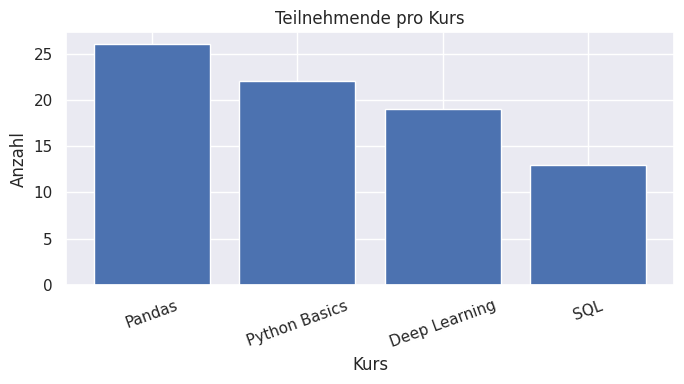

In [ ]:
course_counts = df["course"].value_counts()

plt.figure(figsize=(7,4))
plt.bar(course_counts.index, course_counts.values)
plt.title("Teilnehmende pro Kurs")
plt.xlabel("Kurs")
plt.ylabel("Anzahl")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### **4) Histogramm: Verteilung der Lernstunden**

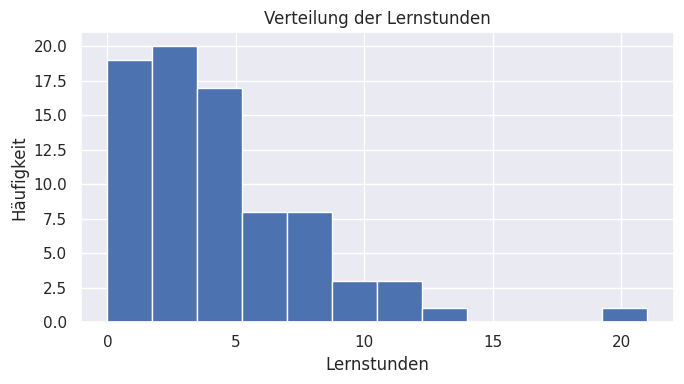

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df["study_hours"], bins=12)
plt.title("Verteilung der Lernstunden")
plt.xlabel("Lernstunden")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.show()

### **5) Scatterplot: Lernstunden vs. Zufriedenheit**

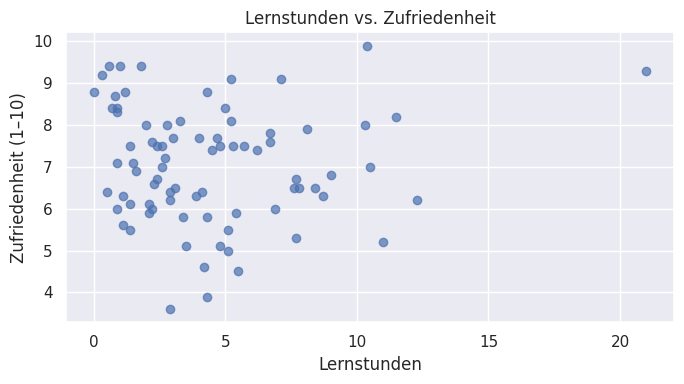

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["satisfaction"], alpha=0.7)
plt.title("Lernstunden vs. Zufriedenheit")
plt.xlabel("Lernstunden")
plt.ylabel("Zufriedenheit (1–10)")
plt.tight_layout()
plt.show()

### **6) Boxplot: Zufriedenheit nach Kurs (Ausreißer + Vergleich)**

**Unterer Whisker:**
Der kleinste Wert, der noch innerhalb von Q1−1,5×IQR liegt

**Oberer Whisker:**
Der größte Wert, der noch innerhalb von Q3+1,5×IQR liegt

IQR=Q3−Q1

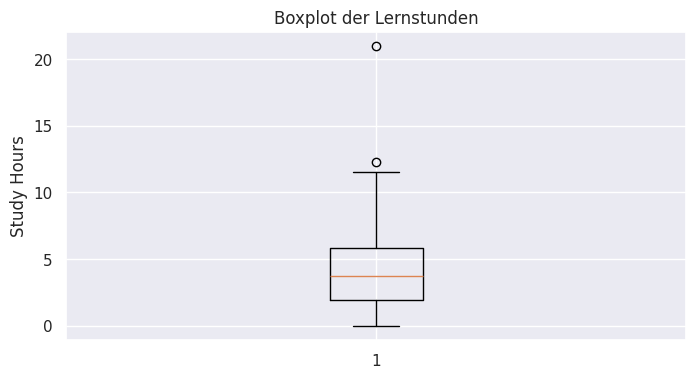

In [ ]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["study_hours"])
plt.title("Boxplot der Lernstunden")
plt.ylabel("Study Hours")
plt.show()

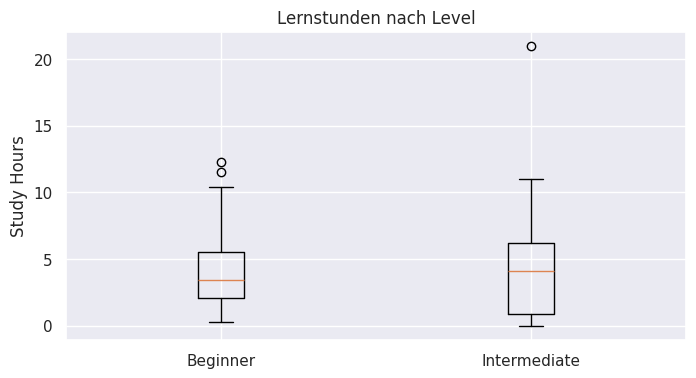

In [ ]:
plt.figure(figsize=(8, 4))

beginner = df[df["level"] == "Beginner"]["study_hours"]
intermediate = df[df["level"] == "Intermediate"]["study_hours"]
plt.boxplot([beginner, intermediate], tick_labels=["Beginner", "Intermediate"])
plt.title("Lernstunden nach Level")
plt.ylabel("Study Hours")
plt.show()

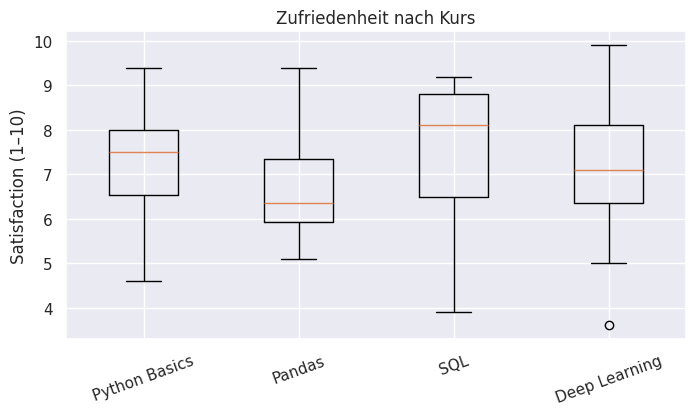

In [ ]:
plt.figure(figsize=(8, 4))

courses = ["Python Basics", "Pandas", "SQL", "Deep Learning"]
data = [df[df["course"] == c]["satisfaction"] for c in courses]
plt.boxplot(data, tick_labels=courses)
plt.title("Zufriedenheit nach Kurs")
plt.ylabel("Satisfaction (1–10)")
plt.xticks(rotation=20)
plt.show()

### **B) Seaborn Beispiele**

### Seaborn – schöner & statistischer

Inhalte

- Unterschied Matplotlib vs. Seaborn

- Warum Seaborn für Data Projekt?

Wichtige Plots:

- sns.barplot

- sns.boxplot

- sns.histplot

- sns.scatterplot

Praxis

- Visualisierung direkt aus Pandas-DataFrames

- Automatische Aggregationen & Konfidenzintervalle

### **6) Boxplot: Zufriedenheit nach Kurs (Ausreißer + Vergleich)**

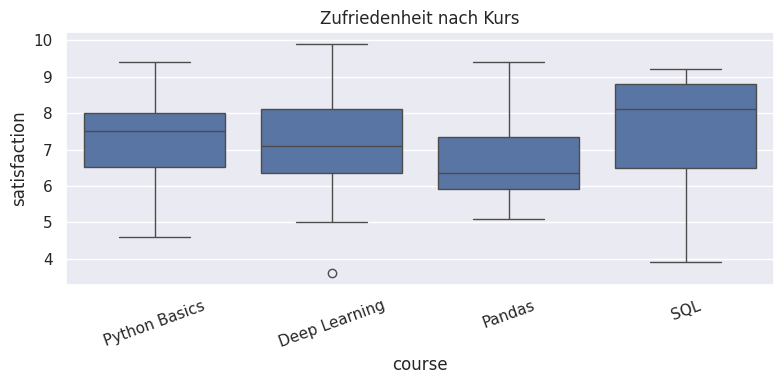

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="course", y="satisfaction")
plt.title("Zufriedenheit nach Kurs")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### **7) Barplot: Durchschnittliche Zufriedenheit je Kurs**

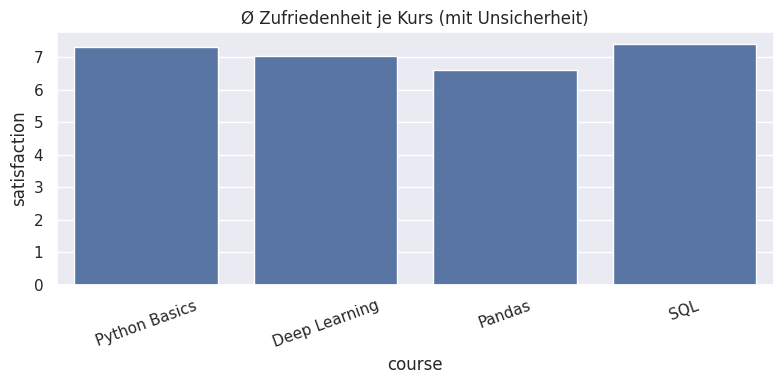

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=df,
    x="course",
    y="satisfaction",
    estimator="mean",
    errorbar=None
)
plt.title("Ø Zufriedenheit je Kurs (mit Unsicherheit)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### **8) Scatterplot mit Farbe (Hue): Level als Gruppe**

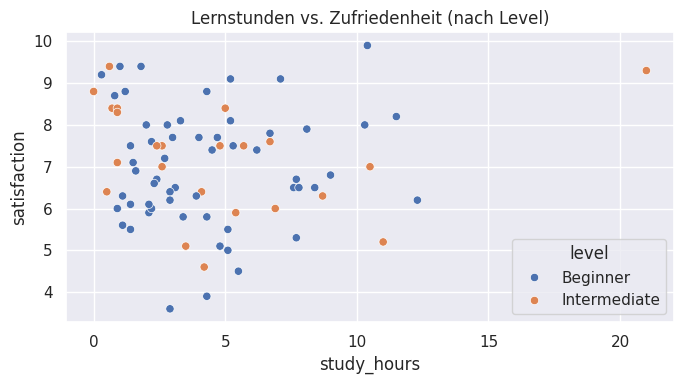

In [ ]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x="study_hours", y="satisfaction", hue="level")
plt.title("Lernstunden vs. Zufriedenheit (nach Level)")
plt.tight_layout()
plt.show()

### **9) Optional: Heatmap (Korrelation numerischer Variablen)**

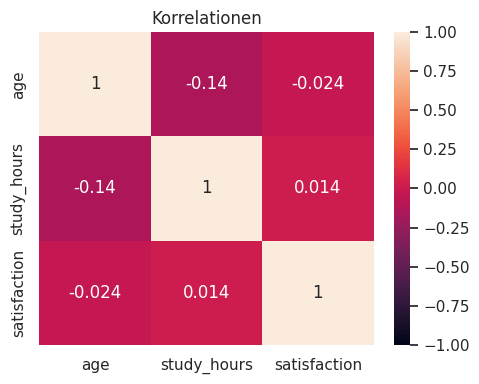

In [ ]:
corr = df[["age","study_hours","satisfaction"]].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1)
plt.title("Korrelationen")
plt.tight_layout()
plt.show()

## **Part 2 mit Fitness-Daten**

Nach dem Hauptbeispiel könnt ihr dieselben Visualisierungsideen auf Fitness-Daten übertragen. Diese Variante ist als Vergleich gedacht, nicht als Ersatz für den vorherigen Case.

### 0) Fitness Setup

Wir verbinden Buchungen, Mitglieder und Kurse zu einem DataFrame `fitness_viz`.

In [ ]:
FITNESS_DIR = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/fitness/'

fitness_bookings = pd.read_csv(FITNESS_DIR + 'fitness_bookings.csv')
fitness_members = pd.read_csv(FITNESS_DIR + 'fitness_members.csv')
fitness_classes = pd.read_csv(FITNESS_DIR + 'fitness_classes.csv')

fitness_viz = (
    fitness_bookings
    .merge(fitness_members, on='member_id', how='left')
    .merge(fitness_classes, on='class_id', how='left')
)
fitness_viz['revenue'] = fitness_viz['price']

fitness_viz.head()

,booking_id,member_id,class_id,name,level,class_name,trainer,price,revenue
0,3001,10,214,Julian Becker,Intermediate,Strength Circuit,Anna,17,17
1,3002,1,215,Olivia Martin,Intermediate,Boxing Conditioning,Max,14,14
2,3003,15,202,Marie Klein,Advanced,Beginner Pilates,Julia,10,10
3,3004,11,202,Lena Schulz,Intermediate,Beginner Pilates,Julia,10,10
4,3005,12,219,Patrick Wolf,Advanced,Recovery Stretch,Tom,12,12


### Fitness Checks

Bevor wir plotten, prüfen wir kurz Struktur und zentrale Spalten.

In [ ]:
fitness_viz.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   booking_id  50 non-null     int64
 1   member_id   50 non-null     int64
 2   class_id    50 non-null     int64
 3   name        50 non-null     str  
 4   level       50 non-null     str  
 5   class_name  50 non-null     str  
 6   trainer     50 non-null     str  
 7   price       50 non-null     int64
 8   revenue     50 non-null     int64
dtypes: int64(5), str(4)
memory usage: 3.6 KB


In [ ]:
fitness_viz[['level', 'class_name', 'trainer', 'price', 'revenue']].describe(include='all')

,level,class_name,trainer,price,revenue
count,50,50,50,50.000000,50.000000
unique,3,18,4,NaN,NaN
top,Intermediate,Boxing Conditioning,Tom,NaN,NaN
freq,22,8,17,NaN,NaN
mean,NaN,NaN,NaN,19.960000,19.960000
std,NaN,NaN,NaN,6.608467,6.608467
min,NaN,NaN,NaN,10.000000,10.000000
25%,NaN,NaN,NaN,14.000000,14.000000
50%,NaN,NaN,NaN,19.000000,19.000000
75%,NaN,NaN,NaN,26.000000,26.000000


### **A) Matplotlib Beispiele mit Fitness-Daten**

### 1) Balkendiagramm: Buchungen pro Level

**Frage:** Welches Mitgliedslevel bucht am häufigsten?

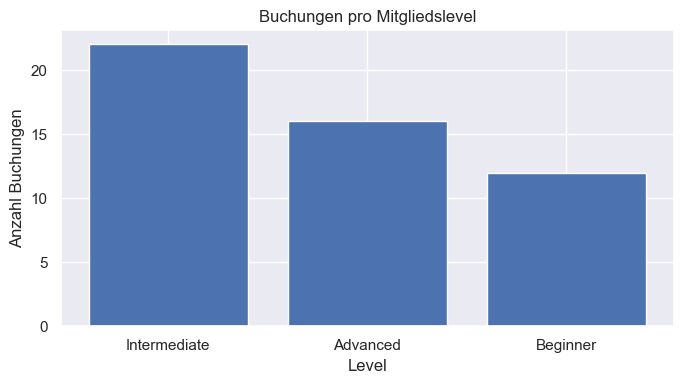

In [ ]:
bookings_by_level_viz = fitness_viz['level'].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(bookings_by_level_viz.index, bookings_by_level_viz.values)
plt.title('Buchungen pro Mitgliedslevel')
plt.xlabel('Level')
plt.ylabel('Anzahl Buchungen')
plt.tight_layout()
plt.show()

### 2) Histogramm: Verteilung der Kurspreise

**Frage:** Sind die meisten Kurse eher günstig oder teuer?

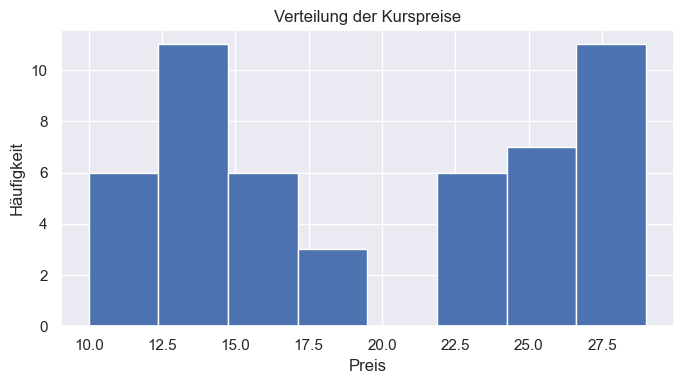

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(fitness_viz['price'], bins=8)
plt.title('Verteilung der Kurspreise')
plt.xlabel('Preis')
plt.ylabel('Häufigkeit')
plt.tight_layout()
plt.show()

### 3) Balkendiagramm: Umsatz pro Trainerin oder Trainer

**Frage:** Wer bringt den höchsten Umsatz?

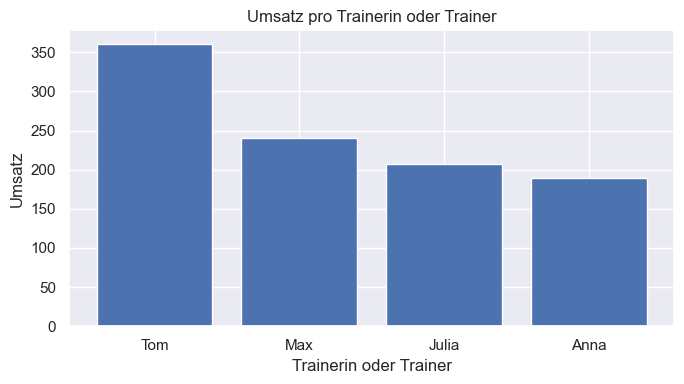

In [ ]:
revenue_by_trainer_viz = (
    fitness_viz
    .groupby('trainer')['revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(revenue_by_trainer_viz.index, revenue_by_trainer_viz.values)
plt.title('Umsatz pro Trainerin oder Trainer')
plt.xlabel('Trainerin oder Trainer')
plt.ylabel('Umsatz')
plt.tight_layout()
plt.show()

## B) Seaborn Beispiele mit Fitness-Daten

### 4) Countplot: Buchungen pro Level

Seaborn zählt Kategorien direkt aus dem DataFrame.

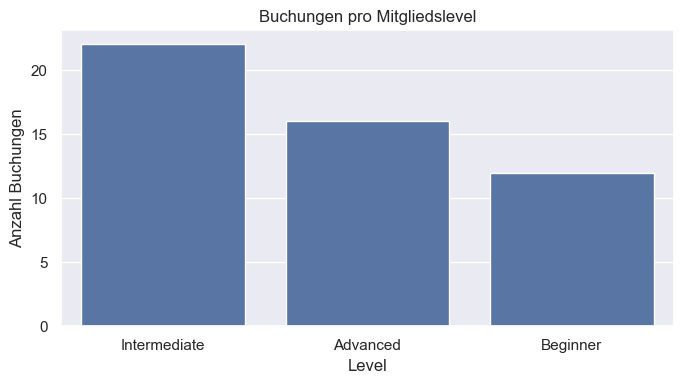

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=fitness_viz, x='level', order=bookings_by_level_viz.index)
plt.title('Buchungen pro Mitgliedslevel')
plt.xlabel('Level')
plt.ylabel('Anzahl Buchungen')
plt.tight_layout()
plt.show()

### 5) Boxplot: Kurspreise nach Level

**Frage:** Buchen manche Level eher teurere Kurse?

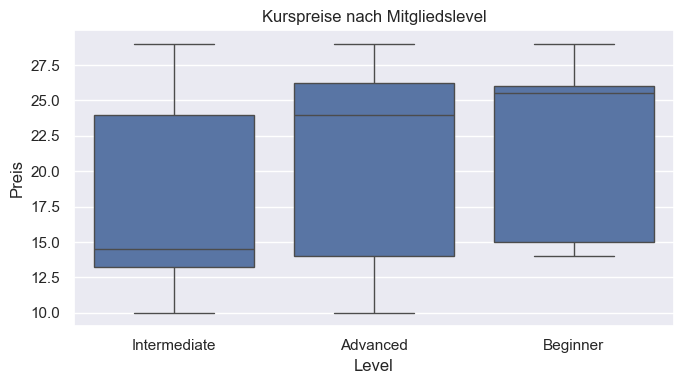

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=fitness_viz, x='level', y='price')
plt.title('Kurspreise nach Mitgliedslevel')
plt.xlabel('Level')
plt.ylabel('Preis')
plt.tight_layout()
plt.show()

### 6) Barplot: Durchschnittlicher Preis pro Level

**Frage:** Welches Level hat den höchsten durchschnittlichen Kurspreis?

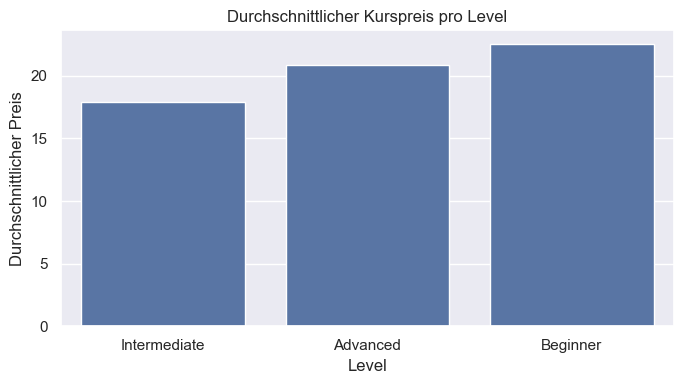

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=fitness_viz, x='level', y='price', estimator='mean', errorbar=None)
plt.title('Durchschnittlicher Kurspreis pro Level')
plt.xlabel('Level')
plt.ylabel('Durchschnittlicher Preis')
plt.tight_layout()
plt.show()

### Fitness-Insight-Fragen

Diskutiert kurz:

- Welche Visualisierung beantwortet welche Frage am besten?
- Wo sieht man nur Anzahl, wo sieht man Umsatz oder Preis?
- Welche Aussage wäre für ein Fitness-Studio relevant?
- Welche Empfehlung könnte aus einem Diagramm folgen?

### **Von Diagrammen zu Insights**

**Inhalte**

- Wie liest man Diagramme richtig?

**Typische Analysefragen:**

- Wo gibt es Ausreißer?

- Gibt es Muster oder auffällige Entwicklungen?

- Gibt es Unterschiede zwischen Gruppen?

- Storytelling mit Daten (kurz & praxisnah)

**Praxis**

- Gemeinsam ein Diagramm interpretieren

- „Was kann man daraus sagen – und was nicht?“

### **Zusammenfassung & Ausblick**

**Inhalte**

- Best Practices für gute Visualisierungen

**Checkliste:**

- Klarer Titel?

- Richtiger Diagrammtyp?

- Lesbare Achsen?

**Ausblick:**

- Kombination mit Pandas & EDA

- Dashboards (z. B. Streamlit, Power BI, Tableau – nur Überblick)

# **14:00–14:20 | ☕ Pause**

# 14:20–15:40 | Fitness-Demo & Shop-Daten Mini-Projekt

Wir üben gemeinsam an einem zweiten Datensatz. Die Logik ist dieselbe wie bei den Shop-Daten:

- Daten verstehen
- filtern
- gruppieren
- Kennzahlen berechnen
- visualisieren
- daraus eine kurze fachliche Aussage ableiten


🎯 Ziel

Am Ende könnt ihr eine bekannte Analyse-Logik auf einen neuen Datensatz übertragen.

Wir arbeiten mit `fitness_joined`: Buchungen, Mitglieder und Kurse in einem DataFrame.

In [ ]:
FITNESS_DIR = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/fitness/'

bookings = pd.read_csv(FITNESS_DIR + 'fitness_bookings.csv')
members = pd.read_csv(FITNESS_DIR + 'fitness_members.csv')
classes = pd.read_csv(FITNESS_DIR + 'fitness_classes.csv')

fitness_joined = (
    bookings
    .merge(members, on='member_id', how='left')
    .merge(classes, on='class_id', how='left')
)
fitness_joined['revenue'] = fitness_joined['price']

fitness_joined.head()

,booking_id,member_id,class_id,name,level,class_name,trainer,price,revenue
0,3001,10,214,Julian Becker,Intermediate,Strength Circuit,Anna,17,17
1,3002,1,215,Olivia Martin,Intermediate,Boxing Conditioning,Max,14,14
2,3003,15,202,Marie Klein,Advanced,Beginner Pilates,Julia,10,10
3,3004,11,202,Lena Schulz,Intermediate,Beginner Pilates,Julia,10,10
4,3005,12,219,Patrick Wolf,Advanced,Recovery Stretch,Tom,12,12


### 1) DataFrame verstehen

**Frage:** Welche Spalten gibt es, welche Datentypen haben sie, und gibt es fehlende Werte?

In [ ]:
fitness_joined.head()

,booking_id,member_id,class_id,name,level,class_name,trainer,price,revenue
0,3001,10,214,Julian Becker,Intermediate,Strength Circuit,Anna,17,17
1,3002,1,215,Olivia Martin,Intermediate,Boxing Conditioning,Max,14,14
2,3003,15,202,Marie Klein,Advanced,Beginner Pilates,Julia,10,10
3,3004,11,202,Lena Schulz,Intermediate,Beginner Pilates,Julia,10,10
4,3005,12,219,Patrick Wolf,Advanced,Recovery Stretch,Tom,12,12


In [ ]:
fitness_joined.columns

Index(['booking_id', 'member_id', 'class_id', 'name', 'level', 'class_name',
       'trainer', 'price', 'revenue'],
      dtype='str')

In [ ]:
fitness_joined.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   booking_id  50 non-null     int64
 1   member_id   50 non-null     int64
 2   class_id    50 non-null     int64
 3   name        50 non-null     str  
 4   level       50 non-null     str  
 5   class_name  50 non-null     str  
 6   trainer     50 non-null     str  
 7   price       50 non-null     int64
 8   revenue     50 non-null     int64
dtypes: int64(5), str(4)
memory usage: 3.6 KB


### 2) Filtern

**Frage:** Welche Buchungen stammen von Mitgliedern mit Level `Advanced`?

In [ ]:
advanced_bookings = fitness_joined.loc[fitness_joined['level'] == 'Advanced']
advanced_bookings.head()

,booking_id,member_id,class_id,name,level,class_name,trainer,price,revenue
2,3003,15,202,Marie Klein,Advanced,Beginner Pilates,Julia,10,10
4,3005,12,219,Patrick Wolf,Advanced,Recovery Stretch,Tom,12,12
5,3006,6,209,Michael Braun,Advanced,Stretch and Mobility,Julia,24,24
6,3007,15,220,Marie Klein,Advanced,Glute Strength,Anna,26,26
8,3009,5,215,Sarah Hoffmann,Advanced,Boxing Conditioning,Max,14,14


### 3) Buchungen pro Level

**KPI:** Anzahl Buchungen pro Mitgliedslevel.

**Frage:** Welches Level ist am aktivsten?

In [ ]:
bookings_by_level = (
    fitness_joined
    .groupby('level')['booking_id']
    .count()
    .sort_values(ascending=False)
)

bookings_by_level

level
Intermediate    22
Advanced        16
Beginner        12
Name: booking_id, dtype: int64

### 4) Umsatz pro Trainerin oder Trainer

**KPI:** Summe der gebuchten Kurspreise pro Trainer:in.

**Frage:** Welche Trainerinnen oder Trainer bringen den höchsten Umsatz?

In [ ]:
revenue_by_trainer = (
    fitness_joined
    .groupby('trainer')['revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_trainer

trainer
Tom      360
Max      241
Julia    207
Anna     190
Name: revenue, dtype: int64

### 5) Beliebteste Kurse

**KPI:** Anzahl Buchungen pro Kurs.

**Frage:** Welche fünf Kurse wurden am häufigsten gebucht?

In [ ]:
top_classes = (
    fitness_joined
    .groupby('class_name')['booking_id']
    .count()
    .sort_values(ascending=False)
    .head(5)
)

top_classes

class_name
Boxing Conditioning     8
Glute Strength          5
Bodyweight Basics       4
Athletic Performance    4
Functional Fitness      3
Name: booking_id, dtype: int64

### 6) Durchschnittlicher Preis pro Level

**KPI:** Durchschnittlicher Kurspreis pro Mitgliedslevel.

**Frage:** Gibt es Level, die eher teurere Kurse buchen?

In [ ]:
avg_price_by_level = (
    fitness_joined
    .groupby('level')['price']
    .mean()
    .sort_values(ascending=False)
)

avg_price_by_level

level
Beginner        22.500000
Advanced        20.875000
Intermediate    17.909091
Name: price, dtype: float64

### 7) Visualisierung

**Diagramm:** Balkendiagramm

**Frage:** Wie verteilt sich der Umsatz auf Trainerinnen und Trainer?

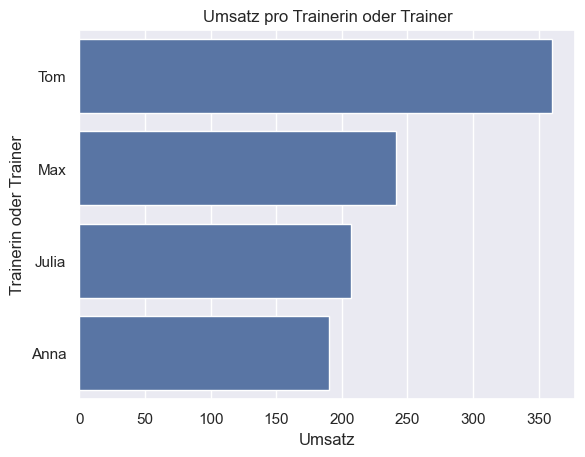

In [ ]:
trainer_plot_data = revenue_by_trainer.reset_index()
trainer_plot_data.columns = ['trainer', 'revenue']

sns.barplot(data=trainer_plot_data, x='revenue', y='trainer')
plt.title('Umsatz pro Trainerin oder Trainer')
plt.xlabel('Umsatz')
plt.ylabel('Trainerin oder Trainer')
plt.show()

### Gemeinsame Interpretation

Diskutiert kurz:

- Welches Mitgliedslevel ist besonders aktiv?
- Welche Kurse oder Trainer:innen fallen auf?
- Welche KPI würdet ihr einem Fitness-Studio zuerst zeigen?
- Welche Empfehlung könnte daraus folgen?

Hilfssatz:

- Ich sehe ...
- Das deutet darauf hin, dass ...
- Deshalb empfehlen wir ...

# 15:40–16:00 | Ergebnisse & Diskussion

Kurze Präsentation der Ergebnisse, Reflexion und offene Fragen.

## Zusammenfassung Tag 3

Heute hast du den Wechsel von SQL zu Python geschafft:

- Python hilft bei Logik, Automatisierung und wiederholbaren Analysen.
- Pandas macht tabellarische Daten in Python gut bearbeitbar.
- Visualisierungen helfen, Muster und Ausreißer schneller zu erkennen.
- Für gute Analysen brauchst du weiterhin dieselbe Denkweise wie in SQL: klare Fragen, saubere Daten und nachvollziehbare Schritte.


## Ausblick auf morgen

Morgen wechseln wir von Python-Grundlagen und ersten Visualisierungen zu echter explorativer Datenanalyse:

- Rohdaten systematisch prüfen
- fehlende Werte, Duplikate und Textformate bereinigen
- Verteilungen, Gruppenunterschiede und Korrelationen interpretieren
- Analyseergebnisse in kurze Reports übersetzen
